# Project Assignment week 1 (CIFAR CNN)

The purpose of the project assignment is to compare CNN (Convolutional Neural Network) and FCN (Fully Connected Network). The idea of the exercise is to compare the both models
1. Performance
2. Learning curve
3. Training time

In this document we implemented Convolutional Neural Network (CNN) for classifying images from CIFAR-10 datasets that consist 60,000 images.

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.regularizers import l2
from keras import models

from keras import backend as K
print(K.backend())

I0000 00:00:1774542537.331001     818 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774542537.968282     818 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774542540.552192     818 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tensorflow


## CIFAR-10 Dataset understanding

After imports we can inspect loaded datasets. In this codeblock, we loaded datasets using 'cifar10.load_data()' function. The datasets consists of 50,000 training and 10,000 test images across 10 classes. Each image is 32x32 pixel color image and each label representing the class of the image.

0. Airplane
1. automobile
2. bird
3. cat
4. deer
5. dog
6. frog
7. horse
8. ship
9. truck

Each label is an integer.

/home/ilkka/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training time: (50000, 32, 32, 3)


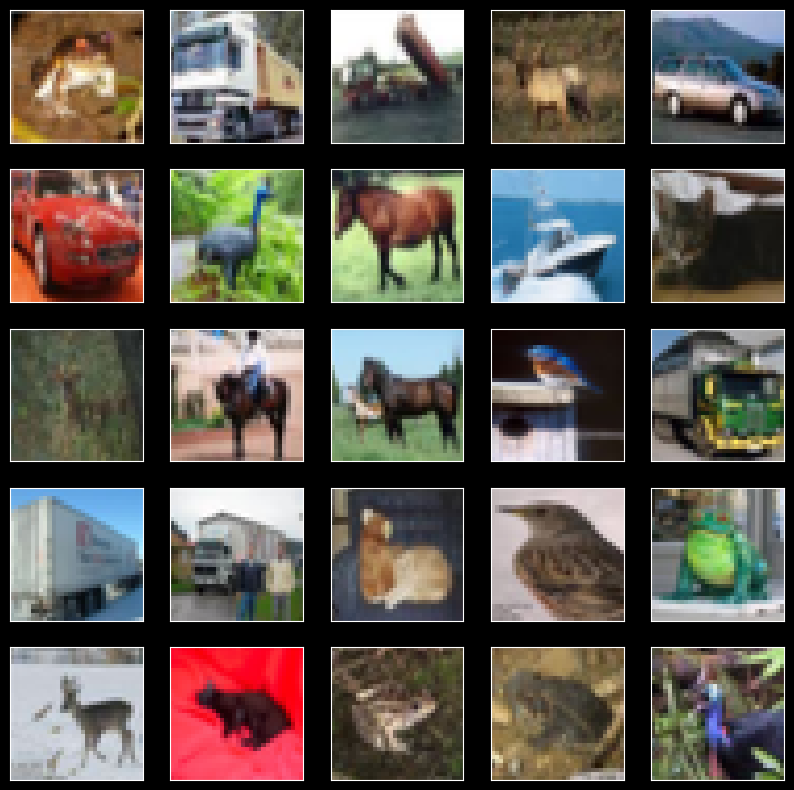

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

train_images = x_train / 255.0
test_images = x_test / 255.0

train_labels = keras.utils.to_categorical(y_train, num_classes=10)
test_labels = keras.utils.to_categorical(y_test, num_classes=10)

print(f"Training time: {train_images.shape}")

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
plt.show()


## Building Convolutional Neural Network (CNN)

For the image classification task, we implemented a Convolutional Neural Network (CNN). The architecture consists of three main convolutional blocks. Each block contains two Conv2D layers followed by BatchNormalization and MaxPooling

Key design choices

1. Batch Normalization: Used to stabilize and accelerate the training process by normalizing the activations of each layer.
2. Dropout: Gradually increasing dropout rates (from 0.2 to 0.5) were applied to prevent overfitting by forcing the network to learn redundant representations.
3. Padding='same': This ensures that the spatial dimensions of the images are preserved during convolution, preventing the loss of information at the borders."

In [4]:
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Decision block
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/home/ilkka/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774542545.654059     818 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774542545.654478    1133 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774542545.684148     818 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if y

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

The learning curves illustrate the progression of the model's accuracy and loss over 10 epochs. Both training and validation accuracy show a steady upward trend.

The fact that the validation accuracy closely follows the training accuracy suggests that the model generalizes well to unseen data.

In [5]:
history = model.fit(train_images, train_labels, epochs=10,
                    batch_size=64,
                    validation_data=(test_images, test_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - accuracy: 0.4879 - loss: 1.5004 - val_accuracy: 0.6388 - val_loss: 1.0172
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 81ms/step - accuracy: 0.6460 - loss: 1.0088 - val_accuracy: 0.6782 - val_loss: 0.9201
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.6975 - loss: 0.8714 - val_accuracy: 0.6746 - val_loss: 0.9562
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 77ms/step - accuracy: 0.7268 - loss: 0.7925 - val_accuracy: 0.7384 - val_loss: 0.7550
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 77ms/step - accuracy: 0.7471 - loss: 0.7305 - val_accuracy: 0.6899 - val_loss: 0.8951
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 77ms/step - accuracy: 0.7622 - loss: 0.6898 - val_accuracy: 0.7740 - val_loss: 0.6512
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.7769 - loss: 0.6409 - val_accuracy: 0.7704 - val_loss: 0.6781
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.7872 - loss: 0.6077 - 

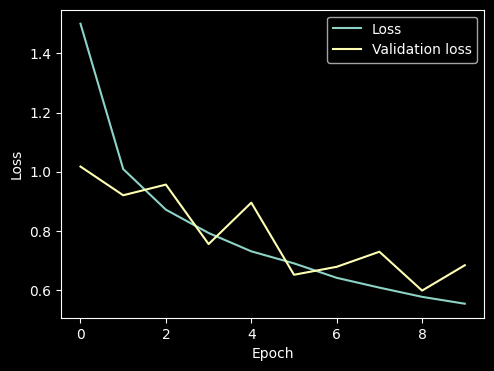

In [6]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

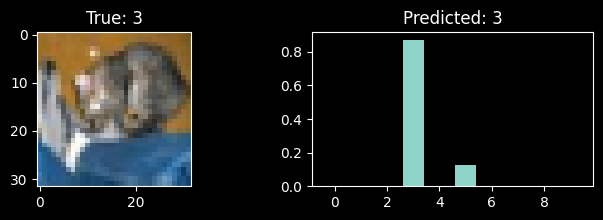

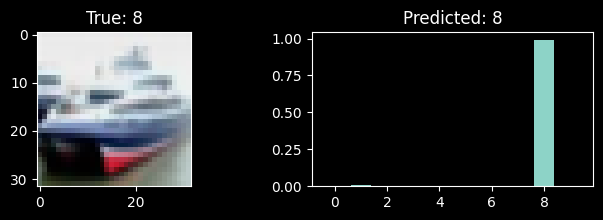

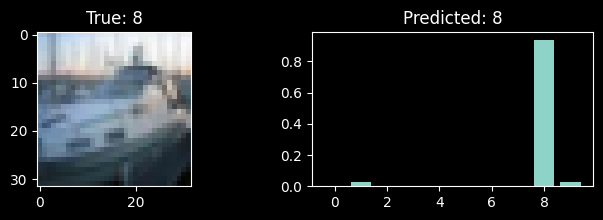

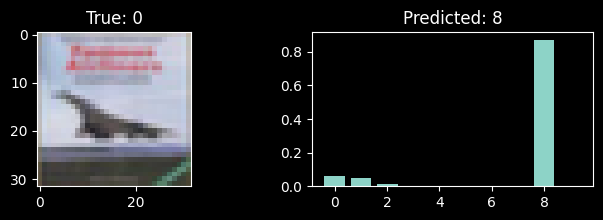

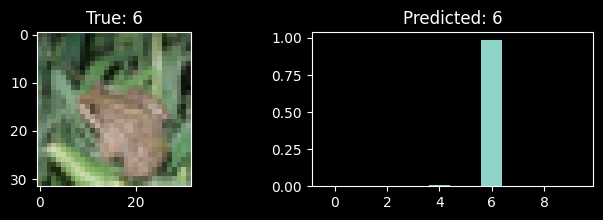

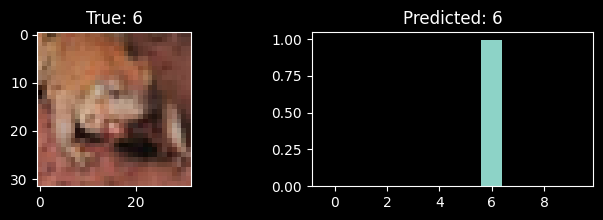

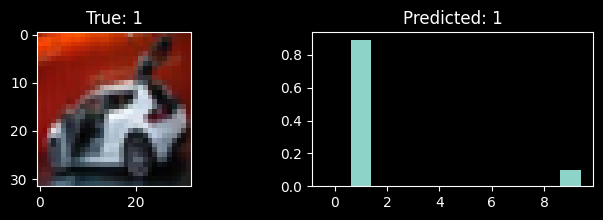

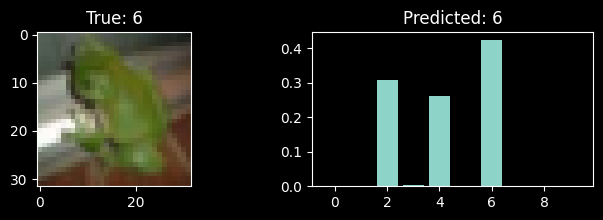

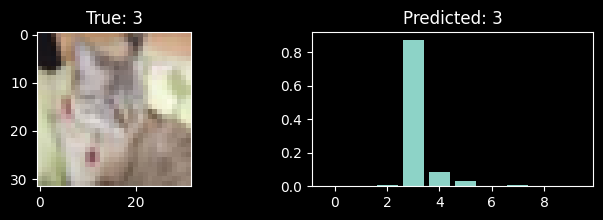

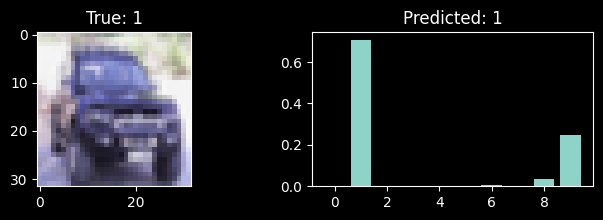

In [9]:
x = test_images
y = model(x)
start = 0

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k])
    plt.title(f"True: {np.argmax(test_labels[start+k])}")
    plt.subplot(1,2,2)
    plt.bar(range(10), y[start+k])
    plt.title(f"Predicted: {np.argmax(y[start+k])}")
    plt.show()